# Exploring the analysis sample

**What this notebook is:** a look at the built sample — who is in it, how the
groups differ, what the price adjustment does, and which limitations are real.

**What this notebook is not:** the place where anything is *defined*. Every
variable here was constructed in `src/data/build_sample.py`, and every number
the paper reports is produced by `src/analysis/`. If you find yourself deriving
a column below, it belongs upstream instead. Notebooks execute out of order and
do not diff; they cannot be the record of what produced a result.

Run `python -m src.data.make_data` first if the sample does not exist yet.

**Definitions match the paper.** Where a statistic below admits more than one
reasonable definition, this notebook uses the paper's, so no number here
contradicts one there. Three are worth naming because the alternatives are
tempting and give different answers:

| Statistic | Definition used | A plausible alternative |
|---|---|---|
| Price levels | the 2023 wave alone | mean across 2021–2023 (97.62 for Texas, not 97.14) |
| Top-coded share | unweighted | `PERWT`-weighted (41.5% / 34.0%, a few points lower) |
| "Joined a household" | household holds >1 migration group | household holds a non-mover (12.3%, not 16.7%) |

`tests/test_parity.py` pins all three against the R implementation, so a future
edit cannot quietly switch definitions.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from src.analysis.figures import (
    CAPTION_YEAR, COLOR_OFFICIAL, COLOR_REPRICED, GRID, INK, INK_MUTED,
    price_levels,
)
from src.analysis.models import RHS, fit, load_sample, pct_gap

pd.set_option("display.width", 120)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial"],
    "figure.dpi": 110,
    "axes.unicode_minus": False,
})

d = load_sample()
f"{len(d):,} people, {d['hhid'].nunique():,} households, {d['YEAR'].nunique()} survey years"

'981,006 people, 547,600 households, 3 survey years'

## 1. Sample composition

The whole analysis rests on two very small groups. Everything downstream — wide
confidence intervals, the decision not to slice further — follows from this
table.

In [2]:
pd.crosstab(d["grp"], d["YEAR"], margins=True, margins_name="total")

YEAR,2021,2022,2023,total
grp,,,,
CA_stay,173606,174324,176338,524268
CA_to_CA,18280,17037,15446,50763
CA_to_TX,500,540,442,1482
TX_stay,111341,124598,128862,364801
TX_to_TX,12226,13326,13549,39101
TX_to_CA,171,227,193,591
total,316124,330052,334830,981006


The two cross-state mover groups are tiny: **1,482** California-to-Texas movers
and **591** in the other direction, against half a million California stayers.
Spread across three years that is roughly 400–540 movers per wave.

This is the binding constraint on the whole study. It is why the confidence
intervals on those two rows dominate the figure, why the analysis pools years
rather than estimating a trend, and why there is no attempt to split movers by
metro, industry, or income band — any such cut lands in the low hundreds and
stops supporting inference.

## 2. Who moves

Movers are not a random sample of stayers. This table is the reason the models
carry controls at all, and the reason the paper is careful to call itself
descriptive.

In [3]:
def wmean(g, col):
    return np.average(g[col], weights=g["PERWT"])

profile = pd.DataFrame([
    {
        "n": len(g),
        "mean age": wmean(g, "age"),
        "BA or more": wmean(g, "ba"),
        "female": wmean(g, "female"),
        "married": wmean(g, "married"),
        "has kids": wmean(g, "kids"),
        "family size": wmean(g, "famsize"),
        "Hispanic": np.average(g["raceth"].eq("Hispanic"), weights=g["PERWT"]),
        "non-citizen": np.average(g["nativity"].eq("Non-citizen"), weights=g["PERWT"]),
    }
    for _, g in d.groupby("grp", observed=True)
], index=d["grp"].cat.categories)
profile.round(3)

,n,mean age,BA or more,female,married,has kids,family size,Hispanic,non-citizen
CA_stay,524268,44.296,0.369,0.499,0.562,0.509,3.332,0.403,0.172
CA_to_CA,50763,38.339,0.481,0.490,0.441,0.382,2.750,0.328,0.180
CA_to_TX,1482,39.561,0.478,0.472,0.592,0.434,2.846,0.320,0.152
TX_stay,364801,44.172,0.346,0.505,0.617,0.530,3.177,0.391,0.140
TX_to_TX,39101,38.262,0.378,0.496,0.461,0.430,2.768,0.361,0.144
TX_to_CA,591,36.672,0.610,0.480,0.500,0.265,2.489,0.255,0.229


Californians who left for Texas are **younger** (39.6 against 44.3), far more
likely to **hold a bachelor's degree** (47.8% against 36.9%), and live in
**smaller families** (2.85 against 3.33). On education they look almost
identical to people who moved *within* California (48.1%) — movers of any kind
are more educated than stayers, which is a well-known feature of migration
rather than anything specific to Texas.

One thing does set the Texas movers apart from other movers: they are **more
likely to be married** (59.2%) than California stayers (56.2%), while
within-state movers are much *less* likely (44.1%). Moving state lines looks
like a household decision in a way that moving across town does not.

None of this is controlled away by pointing at it. The models hold age,
education, race and ethnicity, nativity, and household composition fixed, but
people choose whether to move, and they choose on things the ACS does not
record — a job offer in hand, family already in Texas, an employer paying for
the relocation. **The estimates below describe differences between groups, not
the effect of moving on anyone.**

## 3. What the price adjustment does

The headline result does not depend on the regression. It is visible in the raw
weighted means, before any control enters.

In [4]:
means = pd.DataFrame([
    {
        "official": wmean(g, "ratio_official"),
        "repriced": wmean(g, "ratio_repriced"),
        "SPM": wmean(g, "rtn"),
    }
    for _, g in d.groupby("grp", observed=True)
], index=d["grp"].cat.categories)

base = means.loc["CA_stay"]
comparison = means.round(3).assign(**{
    "vs CA_stay (official)": (means["official"] / base["official"] - 1).map("{:+.1%}".format),
    "vs CA_stay (repriced)": (means["repriced"] / base["repriced"] - 1).map("{:+.1%}".format),
})
comparison

,official,repriced,SPM,vs CA_stay (official),vs CA_stay (repriced)
CA_stay,3.576,3.186,2.767,+0.0%,+0.0%
CA_to_CA,3.679,3.278,2.932,+2.9%,+2.9%
CA_to_TX,3.662,3.749,3.645,+2.4%,+17.7%
TX_stay,3.403,3.485,3.183,-4.8%,+9.4%
TX_to_TX,3.247,3.325,2.932,-9.2%,+4.4%
TX_to_CA,3.790,3.376,3.113,+6.0%,+6.0%


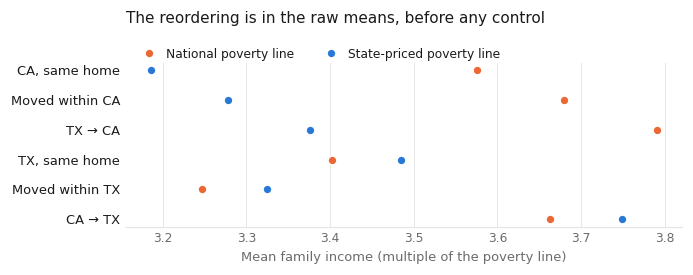

In [5]:
order = ["CA_stay", "CA_to_CA", "TX_to_CA", "TX_stay", "TX_to_TX", "CA_to_TX"]
labels = {"CA_stay": "CA, same home", "CA_to_CA": "Moved within CA",
          "TX_to_CA": "TX \u2192 CA", "TX_stay": "TX, same home",
          "TX_to_TX": "Moved within TX", "CA_to_TX": "CA \u2192 TX"}

fig, ax = plt.subplots(figsize=(6.4, 2.6))
y = np.arange(len(order))[::-1]
for col, color, lab in [("official", COLOR_OFFICIAL, "National poverty line"),
                        ("repriced", COLOR_REPRICED, "State-priced poverty line")]:
    ax.plot(means.loc[order, col], y, "o", color=color, markersize=6,
            markeredgecolor="white", markeredgewidth=1.2, linestyle="none", label=lab)

ax.set_axisbelow(True)
ax.xaxis.grid(True, color=GRID, linewidth=0.6)
ax.yaxis.grid(False)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.set_yticks(y)
ax.set_yticklabels([labels[g] for g in order], fontsize=8.5, color=INK)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=INK_MUTED, labelsize=8, length=0)
ax.set_xlabel("Mean family income (multiple of the poverty line)",
              fontsize=8.5, color=INK_MUTED)
ax.set_title("The reordering is in the raw means, before any control",
             fontsize=10, color=INK, loc="left", pad=26)
leg = ax.legend(frameon=False, fontsize=8, loc="upper left",
                bbox_to_anchor=(0, 1.16), ncol=2, handletextpad=0.4)
for t in leg.get_texts():
    t.set_color(INK)
plt.tight_layout()
plt.show()

Against the **national** line, a California-to-Texas mover sits at 3.66 times
the poverty threshold and a California stayer at 3.58 — a difference of
**+2.4%**, small enough to ignore. Reprice each family's threshold to the
prices it actually faces and the same incomes give **+17.7%**.

Nothing about anyone's income changed between those two columns. The only thing
that moved is the denominator: in 2023 California's price level runs about
**12% above** the national average (RPP 112.20) and Texas's about **3% below**
(97.14).

Note also that the reordering is not confined to the movers. Under the official
line, all three California groups out-rank all three Texas groups. Under the
repriced line, every Texas group overtakes them. That is what a single
statewide index does, and it is worth being clear that the result is driven by
one published number per state per year rather than by anything measured about
the households themselves.

## 4. Top-coding is the sample's most serious limitation

`POVERTY` is capped at both ends: 1 at the bottom, 501 at the top. That ceiling
is not a rare edge case here.

In [6]:
# RPP is quoted for a single wave, matching the paper -- see
# src.analysis.figures.price_levels for why not a multi-year mean. The
# top-coded share is unweighted, also matching the paper; the weighted share
# is a few points lower (41.5% / 34.0%) because PERWT down-weights the
# oversampled groups that cluster below the ceiling.
rpp_ca, rpp_tx = price_levels(d)

ceiling = pd.DataFrame([
    {
        "state": lab,
        f"RPP ({CAPTION_YEAR})": rpp,
        "share at ceiling": d.loc[d["STATEFIP"] == fips, "topcoded"].mean(),
        "repriced ceiling (x line)": 5.01 / (rpp / 100),
    }
    for fips, lab, rpp in [(6, "California", rpp_ca), (48, "Texas", rpp_tx)]
]).set_index("state")
ceiling.round(3)

,RPP (2023),share at ceiling,repriced ceiling (x line)
state,,,
California,112.195,0.445,4.465
Texas,97.140,0.373,5.158


About **44% of Californians and 37% of Texans** sit at the ceiling, their true
position unobserved. Worse, repricing makes the ceiling *state-dependent*:
the same code 501 means **4.47×** the local line in California but **5.16×** in
Texas.

The direction of that bias is knowable even though its size is not. The
California ceiling binds lower, so California's upper tail is compressed harder
than Texas's, and the estimated Texas advantage is **understated** rather than
inflated. That is the reassuring direction — the finding survives the
limitation — but it should be stated in the paper rather than left for a
reader to work out.

## 5. Why the standard errors are clustered

IPUMS samples whole households, and income relative to need is a *family*
measure, so household members are close to duplicate observations of the same
outcome.

In [7]:
sizes = d.groupby("hhid").size()
pd.Series({
    "people": len(d),
    "households": d["hhid"].nunique(),
    "mean sampled adults per household": len(d) / d["hhid"].nunique(),
    "share of people sharing a household": float(d["hhid"].map(sizes).gt(1).mean()),
}).round(3)

people                                 981006.000
households                             547600.000
mean sampled adults per household           1.791
share of people sharing a household         0.797
dtype: float64

Nearly **80% of people in the sample share a household with another sampled
adult**. Treating them as independent would overstate the effective sample size
by close to a factor of two and shrink every standard error accordingly —
which matters most exactly where the evidence is thinnest, on the two
cross-state mover groups.

Hence `cov_type="cluster"` on `hhid` throughout. Note that `hhid` is
`YEAR_SERIAL`, not `SERIAL`: the serial number is unique only within a survey
wave, so clustering on it alone would merge unrelated households across years.

## 6. Where the estimate comes from

The reported +10.1% is what survives after controls. Watching it shrink shows
which differences between movers and stayers are doing the work.

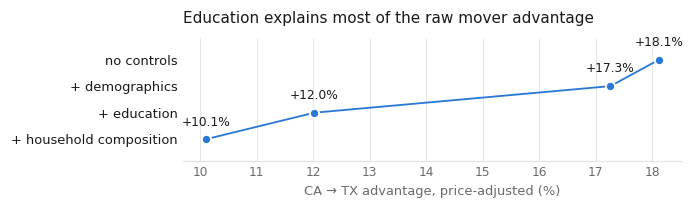

In [8]:
ladder = pd.Series({name: pct_gap(fit(d, "log_repriced", rhs))
                    for name, rhs in RHS.items()})
rungs = {"base": "no controls", "demo": "+ demographics",
         "edu": "+ education", "hh": "+ household composition"}

fig, ax = plt.subplots(figsize=(6.4, 2.0))
y = np.arange(len(ladder))[::-1]
ax.plot(ladder.values * 100, y, "o-", color=COLOR_REPRICED, markersize=6,
        linewidth=1.2, markeredgecolor="white", markeredgewidth=1.2)
for yi, v in zip(y, ladder.values):
    ax.annotate(f"{v:+.1%}", (v * 100, yi), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8, color=INK)

ax.set_axisbelow(True)
ax.xaxis.grid(True, color=GRID, linewidth=0.6)
ax.yaxis.grid(False)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.set_yticks(y)
ax.set_yticklabels([rungs[k] for k in ladder.index], fontsize=8.5, color=INK)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=INK_MUTED, labelsize=8, length=0)
ax.set_ylim(-0.8, len(ladder) - 0.2)
ax.set_xlabel("CA \u2192 TX advantage, price-adjusted (%)", fontsize=8.5, color=INK_MUTED)
ax.set_title("Education explains most of the raw mover advantage",
             fontsize=10, color=INK, loc="left", pad=10)
plt.tight_layout()
plt.show()

The raw gap is **+18.1%**. Demographics barely touch it (+17.3%) — movers and
stayers differ little on age and sex once weighted. **Education takes it to
+12.0%**, the single largest step, which follows directly from the profile
table: movers are far more likely to hold a degree, and degrees pay. Household
composition takes it the rest of the way to **+10.1%**.

So roughly 45% of the raw advantage is compositional — who moves, not where
they moved to. The remaining +10.1% is what the paper reports, and it is a
difference between comparable people rather than an effect of the move.

## 7. Two checks worth running

**Does the result depend on the poverty measure?** The Supplemental Poverty
Measure redefines both resources and threshold, including its own geographic
adjustment, so it is an independent route to the same question.

**Do movers who join an established household drive it?** Migration is recorded
per person but income relative to need is a family measure, so a mover who
joins an existing household is credited with that household's resources.

In [9]:
spm_gap = pct_gap(fit(d, "log_rtn", RHS["hh"]))

# "Joined an established household" = lives in a household holding MORE THAN
# ONE migration group, matching the paper. Note this is broader than "lives
# with a non-mover": a household containing two different mover groups counts
# too, and the narrower definition would understate the exposure (12.3%
# against 16.7%).
groups_per_hh = d.groupby("hhid")["grp"].nunique()
mixed_hh = set(groups_per_hh[groups_per_hh > 1].index)

movers = d["grp"].eq("CA_to_TX")
joined = movers & d["hhid"].isin(mixed_hh)
share_joined = joined.sum() / movers.sum()
gap_excluding = pct_gap(fit(d[~joined], "log_repriced", RHS["hh"]))

pd.Series({
    "repriced gap (reported)": pct_gap(fit(d, "log_repriced", RHS["hh"])),
    "official gap": pct_gap(fit(d, "log_official", RHS["hh"])),
    "SPM gap": spm_gap,
    "share of CA->TX movers in a mixed household": share_joined,
    "repriced gap excluding those movers": gap_excluding,
}).map("{:+.4f}".format)

repriced gap (reported)                        +0.1010
official gap                                   -0.0391
SPM gap                                        +0.1791
share of CA->TX movers in a mixed household    +0.1673
repriced gap excluding those movers            +0.0806
dtype: object

**The SPM agrees, emphatically.** A wholly different resource and threshold
definition gives **+17.9%** where the repriced official measure gives +10.1%.
The two measures are not interchangeable — the SPM moves resources and
threshold at once, so its larger figure cannot be attributed to geography
alone, which is precisely why it is a robustness check rather than the headline
— but the sign and rough magnitude hold up under a definition that shares
almost nothing with the primary one.

**The joined-household concern is real but not fatal.** **16.7%** of
California-to-Texas movers live in a household that also contains a different
migration group, so their family-level income partly reflects resources of
people already at the destination. Dropping them moves the estimate from
+10.1% to **+8.1%** — a meaningful shrink, worth reporting, and not enough to
overturn the result or the sign reversal against the official line.

## What this notebook does not establish

Worth stating plainly, since every number above is a group difference and none
of them is a causal effect.

1. **Selection is unaddressed.** People choose to move, on information the ACS
   never records. Section 2 shows the observable differences; the unobservable
   ones are the reason this is descriptive work.
2. **One index per state per year.** BEA RPP is statewide. Movers cluster in
   particular metros — Austin and Dallas are not rural Texas — and a statewide
   number cannot see that. Metro-level RPPs exist and would be the obvious
   extension.
3. **A one-year migration window.** `MIGPLAC1` asks where someone lived twelve
   months ago, so this is a snapshot of recent movers, not of how they fare
   after settling. People who moved and returned are invisible.
4. **Top-coding compresses the tails**, state-dependently, in the direction of
   understating the gap (section 4).
5. **`PERWT` as a regression weight is not a full design-based estimator.**
   Combined with household clustering it is a reasonable approximation, but
   replicate weights would be the rigorous route and the paper should not claim
   more than it does.